# Модель для предсказания массы черепах
* Цель – разработать модель линейной регрессии, которая будет предсказывать массу черепах. Модель будет предсказывать нужные значения основываясь на нескольких параметрах: длина и ширина панциря; габариты головы; габариты ласт; количество колец на щитках панциря. После написать функцию, которая будет считать массу черепахи с помощью весов из линейной регрессии. 



## Постановка задачи машинного обучения

- Опишите, какую задачу нужно решить: регрессии или классификации.
- Выберите поле, которое станет целевой переменной.
- Назовите метрики качества модели, которые планируете использовать.
- Опишите критерии успешности проекта с опорой на метрики.


* Решаемая задача – регрессия. Масса черепахи является непрерывной величиной, поэтому нам надо решить задачу регрессии.
* Поле, которое станет целевой переменной в нашей задаче, это – weight. 
* Основная метрика для оценки качества модели – MAE. Но также будут использоватсья и другие метрики для более цельной картины.
* Основные критерий успешности проекта: ошибка линейной регрессии не более 5кг на основе MAE; Значение $R^{2}$ не меньше 0.97.

## Подключение и настройка библиотек

В блоке кода ниже, помимо уже указанных библиотек, импортируйте все остальные, которые планируете использовать для проекта.

In [67]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

## Загрузка датасета

- Загрузите данные из файла `turtles.csv`, путь к файлу: `'/datasets/turtles.csv'`. При использовании метода [read_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html) установите правильные значения для параметров `sep` и `decimal`: в качестве разделителя столбцов используйте символ табуляции (`'\t'`), а в качестве разделителя дробной части — запятую.
- Проверьте, правильно ли прошла загрузка. Данные должны соответствовать описанию в тексте урока.
- С помощью методов библиотеки pandas выведите общие сведения о данных.
- Возможно ли продолжать работу? Если нет — что нужно сделать, чтобы устранить препятствия?

In [68]:
df = pd.read_csv('/datasets/turtles.csv', sep = '\t', decimal = ',')

In [212]:
# Проверяем загрузку датасета и данные, которые в нем есть
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8861 non-null   int64  
 1   binomial_name        8812 non-null   object 
 2   registration number  8832 non-null   object 
 3   shell_length         8774 non-null   float64
 4   shell_width          8861 non-null   int64  
 5   head_length          8715 non-null   float64
 6   head_width           8715 non-null   float64
 7   flipper_length_1     8861 non-null   int64  
 8   flipper_width_1      8861 non-null   int64  
 9   flipper_length_2     8861 non-null   int64  
 10  flipper_width_2      8861 non-null   int64  
 11  flipper_length_3     8760 non-null   float64
 12  flipper_width_3      8760 non-null   float64
 13  flipper_length_4     8760 non-null   float64
 14  flipper_width_4      8760 non-null   float64
 15  circle_count         8861 non-null   i

In [213]:
# Проверяем первые строки датасета
df.head()

,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,20438,Caretta caretta,d89af72662f49ece4d09dec75a8b0166,700.0,381,112.0,82.0,356,205,331,185,270.0,180.0,273.0,144.0,63,3.0,NaN,1703159226,87.687
1,19034,Lepidochelys olivacea,1579c64777de4db1c16e8b7b0d19c45e,341.0,295,65.0,48.0,216,190,229,186,164.0,182.0,180.0,149.0,0,1.0,1.0,1689428175,26.949
2,24689,LEPIDOCHELYS OLIVACEA,bfcec01187569615087e4d777c44985a,408.0,343,71.0,70.0,308,224,285,232,264.0,179.0,268.0,176.0,0,3.0,NaN,1745783111,30.016
3,17945,Lepidochelys Olivacea,2c159675aa28f0ea566fce2090bf4c82,512.0,432,98.0,95.0,334,317,364,284,NaN,NaN,NaN,NaN,3,4.0,1.0,1677757151,33.917
4,24543,lepidochelys olivacea,ecd22499761e2ac56a6d8eb765ec566d,408.0,307,50.0,54.0,280,168,269,218,199.0,165.0,209.0,180.0,0,4.0,1.0,1744455613,28.511


* Типы данных в целом определены корректно: большинство признаков являются числовыми (int64 или float64), а категориальные признаки представлены типом object. Также в некоторых столбцах есть пропущенные значения, поэтому перед обучением модели необходимо будет провести исследовательский анализ данных и обработать пропуски.
* В целом данные соответствуют описанию задания, поэтому можно продолжать работу с датасетом.

## Исследовательский анализ данных

Проведите исследовательский анализ данных:
1. Выясните, данные о каких черепахах представлены в датасете.
2. Проведите отбор записей о нужном виде черепах. Для дальнейшей работы достаточно изучить только *Chelonia mydas*. При этом вы можете сравнить распределение данных об этих черепахах с другими видами, если есть желание и время.
3. Определите, все ли признаки можно использовать для решения задачи. Ответ обоснуйте. Удалите признаки, которые вам никак не помогут.
4. Проверьте, есть ли в данных пропуски. Определите, какие из них можно обработать сразу, а в каких случаях лучше сперва провести разделение на выборки. Решите, стоит ли удалить некоторые пропуски.
5. Определите, есть ли в данных дубликаты. Выберите корректный способ их обработки.
6. Проанализируйте распределение признаков, постройте необходимые для этого визуализации: ящики с усами, гистограммы и так далее. Определите, есть ли в данных выбросы и какие из них критичные. Решите, можно ли их сразу исправить.
7. Проверьте, одинаков ли масштаб признаков. Если он различается, предложите решение этой проблемы.
8. Проанализируйте корреляцию между признаками и целевой переменной с помощью вычислений и графически. Определите, все ли признаки нужны для дальнейшей работы.
9. Проверьте данные на мультиколлинеарность и решите, можно ли её устранить.

### Данные в датасете и фильтрация

In [69]:
# Проверяем все уникальные строки в нужном столцбе
df['binomial_name'].unique()

array(['Caretta caretta', 'Lepidochelys olivacea',
       'LEPIDOCHELYS OLIVACEA', 'Lepidochelys Olivacea',
       'lepidochelys olivacea', 'Chelonia mydas',
       'ERETMOCHELYS IMBRICATA', 'Eretmochelys imbricata',
       'Dermochelys coriacea', 'caretta caretta', 'CARETTA CARETTA',
       'chelonia mydas', 'Chelonia Mydas', 'CHELONIA MYDAS',
       'Dermochelys Coriacea', 'eretmochelys imbricata', nan,
       'Caretta Caretta', 'lepidochelys kempii', 'Lepidochelys kempii',
       'Eretmochelys Imbricata', 'dermochelys coriacea',
       'Lepidochelys Kempii', 'DERMOCHELYS CORIACEA'], dtype=object)

* В датасете есть разные виды черепах. Нам надо отфильтровать датасет.

In [70]:
# Приводим название черепах в нижний регистр
df_copy = df.copy()
df_copy['binomial_name'] = df_copy['binomial_name'].str.lower()
df_copy['binomial_name'].unique()

array(['caretta caretta', 'lepidochelys olivacea', 'chelonia mydas',
       'eretmochelys imbricata', 'dermochelys coriacea', nan,
       'lepidochelys kempii'], dtype=object)

In [71]:
df_filtered = df_copy[df_copy['binomial_name'] == 'chelonia mydas'].copy()

In [72]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2829 entries, 8 to 8859
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   2829 non-null   int64  
 1   binomial_name        2829 non-null   object 
 2   registration number  2825 non-null   object 
 3   shell_length         2794 non-null   float64
 4   shell_width          2829 non-null   int64  
 5   head_length          2790 non-null   float64
 6   head_width           2790 non-null   float64
 7   flipper_length_1     2829 non-null   int64  
 8   flipper_width_1      2829 non-null   int64  
 9   flipper_length_2     2829 non-null   int64  
 10  flipper_width_2      2829 non-null   int64  
 11  flipper_length_3     2798 non-null   float64
 12  flipper_width_3      2798 non-null   float64
 13  flipper_length_4     2798 non-null   float64
 14  flipper_width_4      2798 non-null   float64
 15  circle_count         2829 non-null   i

### Удаление ненужных признаков из датасета
* В данных есть несколько столбцов, от которых можно избавиться. 
1. <b> id </b> – Это номер записи, поэтому линейная регрессия может ошибочно найти взаимосвязь между этой колонкой и весом черепахи.
1. <b> binomial_name </b> – Датасет был отфильтрован и остались данные только о нужном виде черепах, поэтому от этого столбца можно избавиться.
2. <b> registration number </b> – регистрационный черепах не дает никакой релевантной информаций. Для обучение модели нам нужны данные о размерах черепахи.
3. <b> measure_count </b> – Количество сделанных замеров никак не будет использовано моделью для предсказания веса черепахи. 
4. <b> timestamp </b> – момент замера веса черепахи нам не нужен. Он не дает никакой информаций о её размерах. Однако, этот столбец стоит оставить до поиска дубликатов. 
* Однако, столбцы `id`, `regstration_number`, `measure_count`, `timestamp` лучше оставить до удаления явных дубликатов. В датафрейме могут быть данные о размерах об одной и той же черепахе и после удаления данных колонок некоторые строки могут быть ошибочно помечены как дубликаты.

### Пропуски в данных

In [73]:
# Считаем количество пропусков
df_filtered.isna().sum() 

id                        0
binomial_name             0
registration number       4
shell_length             35
shell_width               0
head_length              39
head_width               39
flipper_length_1          0
flipper_width_1           0
flipper_length_2          0
flipper_width_2           0
flipper_length_3         31
flipper_width_3          31
flipper_length_4         31
flipper_width_4          31
circle_count              0
measure_count            81
shell_crack            2152
timestamp                 0
weight                    3
dtype: int64

In [74]:
# Считаем долю пропусков в каждом столцбе
df_filtered.isna().sum() / len(df_filtered) * 100

id                      0.000000
binomial_name           0.000000
registration number     0.141393
shell_length            1.237186
shell_width             0.000000
head_length             1.378579
head_width              1.378579
flipper_length_1        0.000000
flipper_width_1         0.000000
flipper_length_2        0.000000
flipper_width_2         0.000000
flipper_length_3        1.095794
flipper_width_3         1.095794
flipper_length_4        1.095794
flipper_width_4         1.095794
circle_count            0.000000
measure_count           2.863203
shell_crack            76.069282
timestamp               0.000000
weight                  0.106045
dtype: float64

* В большинстве колонок количество пропусков составляет около 1% и в столбце с целевой переменной количество пропущенных значение ещё меньше – около 0.1%. Можно удалить пропуски в данных столбцах, потому что они практический не повлияют на размер выборки и это облегчит дальнейшую работу с датафреймом. 

In [75]:
df_filtered = df_filtered.dropna(
    subset = [
        'registration number',
        'shell_length', 
        'head_length', 
        'head_width', 
        'flipper_length_3', 
        'flipper_width_3', 
        'flipper_length_4',
        'flipper_width_4',
        'measure_count',
        'weight']).copy()

In [76]:
# Проверяем успешность удаления
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2640 entries, 8 to 8859
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   2640 non-null   int64  
 1   binomial_name        2640 non-null   object 
 2   registration number  2640 non-null   object 
 3   shell_length         2640 non-null   float64
 4   shell_width          2640 non-null   int64  
 5   head_length          2640 non-null   float64
 6   head_width           2640 non-null   float64
 7   flipper_length_1     2640 non-null   int64  
 8   flipper_width_1      2640 non-null   int64  
 9   flipper_length_2     2640 non-null   int64  
 10  flipper_width_2      2640 non-null   int64  
 11  flipper_length_3     2640 non-null   float64
 12  flipper_width_3      2640 non-null   float64
 13  flipper_length_4     2640 non-null   float64
 14  flipper_width_4      2640 non-null   float64
 15  circle_count         2640 non-null   i

* Большое количество пропусков есть в столбце <b> shell_crack </b>. Этот столбец говорит о количестве трещин на панцире черепахи. Эти данные могут нести пользу для прогнозов, поэтому надо изучить подробнее прежде чем делать что-либо с ними.
* Сперва, надо проверить уникальные значение в столбце. Возможно, пропуски говорят о том, что у черепахи не было трещин на панцире в момент замеров.

In [77]:
# Выводим уникальные значения столбца
df_filtered['shell_crack'].unique()

array([ 1.,  5., nan,  3.,  2.,  4.])

* Как видно, есть все значение между 1 и 5, но 0 нету. Пропуски в данных могут результатом ошибки, либо же они могут означать, что у черепахи на самом деле нету каких-либо трещин на панцире. Для подтверждения какой-либо версий в датафрейме нету достаточных данных. Но второй вариант кажется более вероятным, потому что в данных нету значения 0 (которое бы говорило об отсутствий трещин на панцире) и все значение идут в порядке возрастания. Между ними нету скачков.

In [78]:
# Заполняем пропуски нужным значением
df_filtered['shell_crack'] = df_filtered['shell_crack'].fillna(0)

In [79]:
# Проверяем исправность изменений.
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2640 entries, 8 to 8859
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   2640 non-null   int64  
 1   binomial_name        2640 non-null   object 
 2   registration number  2640 non-null   object 
 3   shell_length         2640 non-null   float64
 4   shell_width          2640 non-null   int64  
 5   head_length          2640 non-null   float64
 6   head_width           2640 non-null   float64
 7   flipper_length_1     2640 non-null   int64  
 8   flipper_width_1      2640 non-null   int64  
 9   flipper_length_2     2640 non-null   int64  
 10  flipper_width_2      2640 non-null   int64  
 11  flipper_length_3     2640 non-null   float64
 12  flipper_width_3      2640 non-null   float64
 13  flipper_length_4     2640 non-null   float64
 14  flipper_width_4      2640 non-null   float64
 15  circle_count         2640 non-null   i

### Дубликаты в датасете

#### Явные дубликаты

In [80]:
# Проверка столбцах на явные дубликаты
df_filtered.duplicated().sum()

319

* В данных было насчитано 319 явных дубликатов. В теории, габариты разных черепах могут быть идентичными. Но, исходя из факта что единицы измерения – милиметры, этого не может быть. От этих явных дубликатов стоит избавиться.

In [81]:
# Избавляемся от явных дубликатов
df_filtered_4_4 = df_filtered.drop_duplicates(keep = 'first')

#### Не явные дубликаты

* Неявными дубликатами можно считать те строки, в которых совпадают точные данные по типу габаритов черепахи. Веса разных черепах могут совпадать, потому что данные в килограммах. Это не самая точная единица измерения, поэтому значения могут совпадать. 

In [82]:
df_filtered_4_4.duplicated(
    subset = ['shell_length', 
              'shell_width', 
              'head_length', 
              'head_width', 
              'flipper_length_1',  
              'flipper_width_1',
              'flipper_length_2',
              'flipper_width_2',
              'flipper_length_3',
              'flipper_width_3',
              'flipper_length_4',
              'flipper_width_4'
             ]).sum()

0

* Теперь, когда явные и неявные дубликаты были удалены из датафрейме. Можно избавиться от ненужных столбцов.

In [83]:
# Избавляемся от столбцов
df_filtered_4_4 = df_filtered_4_4.drop(columns = ['id', 'binomial_name', 'registration number', 'measure_count', 'timestamp']).copy()


In [84]:
df_filtered_4_4.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2321 entries, 8 to 7840
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   shell_length      2321 non-null   float64
 1   shell_width       2321 non-null   int64  
 2   head_length       2321 non-null   float64
 3   head_width        2321 non-null   float64
 4   flipper_length_1  2321 non-null   int64  
 5   flipper_width_1   2321 non-null   int64  
 6   flipper_length_2  2321 non-null   int64  
 7   flipper_width_2   2321 non-null   int64  
 8   flipper_length_3  2321 non-null   float64
 9   flipper_width_3   2321 non-null   float64
 10  flipper_length_4  2321 non-null   float64
 11  flipper_width_4   2321 non-null   float64
 12  circle_count      2321 non-null   int64  
 13  shell_crack       2321 non-null   float64
 14  weight            2321 non-null   float64
dtypes: float64(9), int64(6)
memory usage: 290.1 KB


### Распределение признаков

* Для экономии времени и избежания ошибок, лучше написать отдельные функций для построения нужных графиков. Сделаем функций для ящика с усами и столбчатой диаграммы. Остальные виды графиков нам пока не нужны.
* В датафрейме столбцы о габаритах каждой отдельной ласты черепахи. Распределение этих данных можно показать на одном графике с несколькими вертикальными ящиками с усами.

#### Функций для выполнения задачи

In [85]:
# ––ЯЩИКИ С УСАМИ––

# Определяем функцию для создания ящика-с-усами
def boxplot_plot(
    dataframe, 
    column_name: str,
    title: str,
    ylabel: str,
    figure_size = (8, 6)
    ):
    # Создаем полотна для графика
    plt.figure(figsize = figure_size)
    
    # Создаем ящик с усами для определенного столбца
    dataframe.boxplot(
        column = column_name,
        vert = False,
        showfliers = True
        )
    
    # Передаем название графика и подписи для осей
    plt.title(title)
    plt.ylabel(ylabel)
    
    return plt.show()

# Определяем функцию для создания нескольких ящиков с усами
def flipper_box_plot(
    dataframe,
    column_name: str,
    title: str,
    ylabel: str,
    figure_size = (8, 6),
    font_size = 20,
    col_num = 4
    ):
    
    # Проверяем, что название колонок было передано правильно
    if (column_name == 'flipper_length' or column_name == 'flipper_width'):
        pass
    else:
        return 'Выбрано неправильное название столбца. Введите "flipper_length" либо "flipper_width"'
    
    # Создаем полотно для графика и передаем нужное количество подграфиков
    fig, axs = plt.subplots(nrows = 1, ncols = col_num, figsize = figure_size, sharey = True )
    
    # Создаем отдельный подграфик для каждой конечности черепахи
    for i in range(1, 5):
        
        # Создаем вертикальный ящик с усами, показывающий выбросы
        dataframe.boxplot(
        column = (column_name + '_' + str(i)),
        vert = True,
        showfliers = True,
        ax = axs[i - 1]
        )
    
    # Передаем название всего графика и 
    fig.suptitle(title, size = font_size)
    axs[0].set_ylabel(ylabel, size = 15)
    plt.tight_layout()
    
    return plt.show()

In [86]:
# ––ГРАФИКИ РАССЕИВАНИЯ И СОВМЕСТНЫЕ РАСПРЕДЕЛЕНИЯ––

# Определяем функцию для построение графика рассеяния между признаком и целевой переменной
def plot_scatterplot(
    dataframe,
    column_name: str,
    title: str,
    xlabel: str,
    color = 'blue',
    edgecolor = 'black',
    dot_size = 50,
    figsize = (8, 6)
    ):

# Создаем график рассеивания с нужными параметрами
    dataframe.plot(
    kind = 'scatter', # Вид графика
    x = column_name, # Название колонки x
    y = 'weight', # Целевая переменная
    alpha = 0.7, # Прозрачность
    color = color, # Цвет точек
    edgecolor = edgecolor, # Цвет края точек
    s = dot_size, # Размер точек
    title = title, # Название графика
    xlabel = xlabel
    )

# Определяем функцию для построения графика совместного распределения 
def joint_plt(
    dataframe,
    x_col: str,
    title: str,
    y_col = 'weight',
    figure_size = (8, 6)
    ):
    
    # Передаем размеры графика
    plt.figure(figsize = figure_size)
    
    # Создаем график совместного распределения
    sns.jointplot(
        data = dataframe,
        x = x_col,
        y = y_col
    )
    
    # Задаем графику название и показываем его
    plt.suptitle(title)
    plt.tight_layout()
    return plt.show()

In [87]:
# ––ГИСТОГРАММЫ––

# Определяем функция для построения гистограммы
def hist_plot(
    dataframe,
    x_col: str,
    title: str,
    xlabel: str,
    ylabel: str,
    legend = True,
    alpha = 0.75,
    edgecolor = 'black',
    hue = 'species',
    figure_size = (8, 6)
    ):
    
    # Создаем полотно для графика и гистограмму
    plt.figure(figsize = figure_size)
    sns.histplot(
        data = dataframe,
        x = x_col,
        legend = legend,
        alpha = alpha,
        edgecolor = edgecolor
    )
    
    # Даем название графику, его осям, и показываем его
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    
    return plt.show()

#### Изучение данных и их фильтрация

* После создания нужных функций, начнем проверять распределение разных признаков черепах по порядку.

In [88]:
df_filtered_4_4.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2321 entries, 8 to 7840
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   shell_length      2321 non-null   float64
 1   shell_width       2321 non-null   int64  
 2   head_length       2321 non-null   float64
 3   head_width        2321 non-null   float64
 4   flipper_length_1  2321 non-null   int64  
 5   flipper_width_1   2321 non-null   int64  
 6   flipper_length_2  2321 non-null   int64  
 7   flipper_width_2   2321 non-null   int64  
 8   flipper_length_3  2321 non-null   float64
 9   flipper_width_3   2321 non-null   float64
 10  flipper_length_4  2321 non-null   float64
 11  flipper_width_4   2321 non-null   float64
 12  circle_count      2321 non-null   int64  
 13  shell_crack       2321 non-null   float64
 14  weight            2321 non-null   float64
dtypes: float64(9), int64(6)
memory usage: 290.1 KB


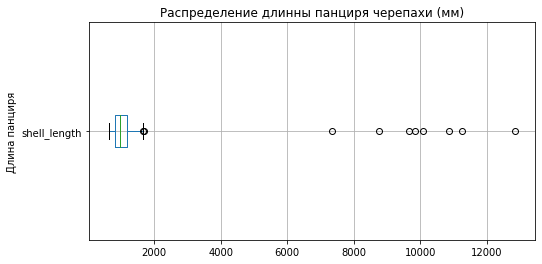

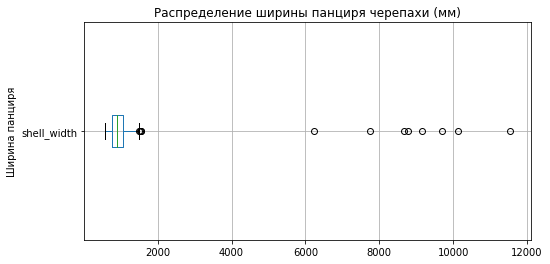

In [89]:
# Делаем ящик с усами для длинны панциря
boxplot_plot(
    dataframe = df_filtered_4_4,
    column_name = 'shell_length',
    title = 'Распределение длинны панциря черепахи (мм)',
    ylabel = 'Длина панциря',
    figure_size = (8, 4))

# Делаем ящик с усами для ширины панциря
boxplot_plot(
    dataframe = df_filtered_4_4,
    column_name = 'shell_width',
    title = 'Распределение ширины панциря черепахи (мм)',
    ylabel = 'Ширина панциря',
    figure_size = (8, 4))

* Сделать какие-либо выводы по распределению пока трудно. Надо избавиться от самых больших выбросов, чтобы работать дальше. Рассчитаем метрики для ширини и длинны панциря, чтобы понять по какому перцентилю надо фильтровать данные.

In [90]:
# Создаем лист с нужными перцентилями
percentiles_list = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]

# Определяем функцию для показа перцентильных значений
def percentile_show(
    dataframe,
    column_name: str,
    percentiles_list: list,
    required_per: float
    ):
    
    # Считаем значение нужного перцентиля и выводим все остальные
    percentile = dataframe[column_name].quantile(required_per)
    print(f"Значение перцентилей колонки '{column_name}' \n {dataframe[column_name].quantile(percentiles_list)}")
    
    return percentile 

# выводим значения перцентилей для shell_length
# Берем в качестве порогового перцентиля 99%
shell_length_thresh = percentile_show(
    dataframe = df_filtered_4_4,
    column_name = 'shell_length',
    percentiles_list = percentiles_list,
    required_per = 0.99
    )

# Делаем тоже самое для shell_width
shell_width_thresh = percentile_show(
    dataframe = df_filtered_4_4,
    column_name = 'shell_width',
    percentiles_list = percentiles_list,
    required_per = 0.99
    )

Значение перцентилей колонки 'shell_length' 
 0.01     692.0
0.05     727.0
0.10     757.0
0.25     839.0
0.50     982.0
0.75    1173.0
0.90    1346.0
0.95    1451.0
0.99    1600.6
Name: shell_length, dtype: float64
Значение перцентилей колонки 'shell_width' 
 0.01     615.2
0.05     652.0
0.10     679.0
0.25     756.0
0.50     893.0
0.75    1056.0
0.90    1226.0
0.95    1308.0
0.99    1447.2
Name: shell_width, dtype: float64


* На boxplot видны экстремально большие значения длины и ширины панциря, которые сильно отличаются от основной массы данных и, вероятно, являются ошибками ввода или измерения. Поэтому для первичной очистки были удалены значения выше 99-го перцентиля

In [91]:
# Фильруем датафрейм на основе высчитанных перцентилей
df_filtered_4_4 = df_filtered_4_4[(df_filtered_4_4['shell_length'] < shell_length_thresh)].copy()
df_filtered_4_4 = df_filtered_4_4[(df_filtered_4_4['shell_width'] < shell_width_thresh)].copy()

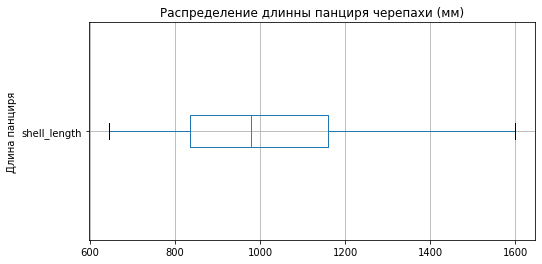

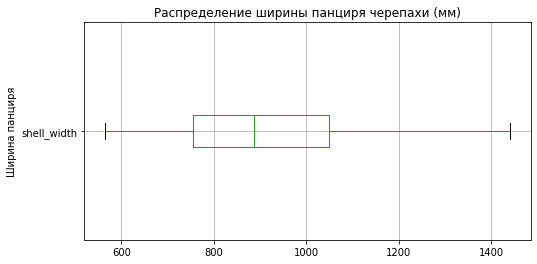

In [92]:
# Делаем ящик с усами для длинны панциря
boxplot_plot(
    dataframe = df_filtered_4_4,
    column_name = 'shell_length',
    title = 'Распределение длинны панциря черепахи (мм)',
    ylabel = 'Длина панциря',
    figure_size = (8, 4))

# Делаем ящик с усами для ширины панциря
boxplot_plot(
    dataframe = df_filtered_4_4,
    column_name = 'shell_width',
    title = 'Распределение ширины панциря черепахи (мм)',
    ylabel = 'Ширина панциря',
    figure_size = (8, 4))

* От выбросов в значениях удалось избавиться. Можно переходить к следующим.

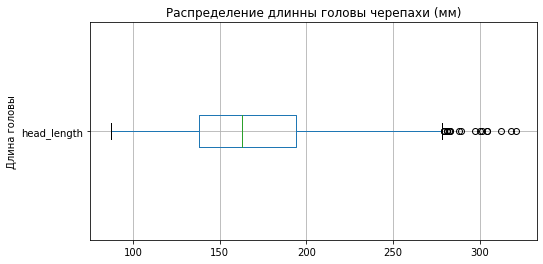

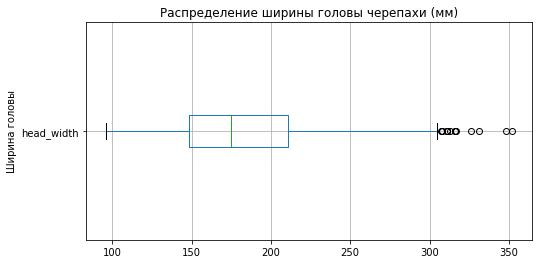

In [93]:
# Делаем ящик с усами для длинны головы
boxplot_plot(
    dataframe = df_filtered_4_4,
    column_name = 'head_length',
    title = 'Распределение длинны головы черепахи (мм)',
    ylabel = 'Длина головы',
    figure_size = (8, 4))

# Делаем ящик с усами для ширины головы
boxplot_plot(
    dataframe = df_filtered_4_4,
    column_name = 'head_width',
    title = 'Распределение ширины головы черепахи (мм)',
    ylabel = 'Ширина головы',
    figure_size = (8, 4))

* Ситуцация с длинной и шириной головы иная. Здесь так же есть большое количество высоких значений. Однако, масштаб данных значений не такой, поэтому считать данные значения выбросами – не разумная идея. Сперва надо проверить совместное распределение этих данных с весом черепах. Если у больших значений так же большой, то можно оставить данные значения.

<Figure size 720x720 with 0 Axes>

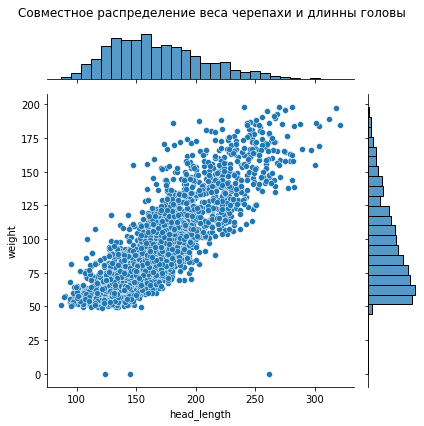

In [94]:
# Создаем график совместного распределения
joint_plt(
    dataframe = df_filtered_4_4,
    x_col = 'head_length',
    title = 'Совместное распределение веса черепахи и длинны головы',
    figure_size = (10, 10))

* Совместное распределение показывает, что у черепах с большой длинной головы так же и большой вес, поэтому эти данные стоит оставить.
* К тому же, на графике видны точки с нулевым весом. У черепахи физический не может быть нулевой вес, поэтому эти данные можно считать ошибочными и их надо удалить.

In [95]:
# Для удобства сделаем копию датафрейма
df_filtered_4_5 = df_filtered_4_4.copy() 
df_filtered_4_5 = df_filtered_4_5[df_filtered_4_5['weight'] > 0]


* Следующим в очереди стоят габариты ласт. В датасете есть значение габаритов для каждой отдельной ласты, поэтому для компактности лучше выводить графики распределения пачками для каждой ласты. Для этого есть написанная функция.

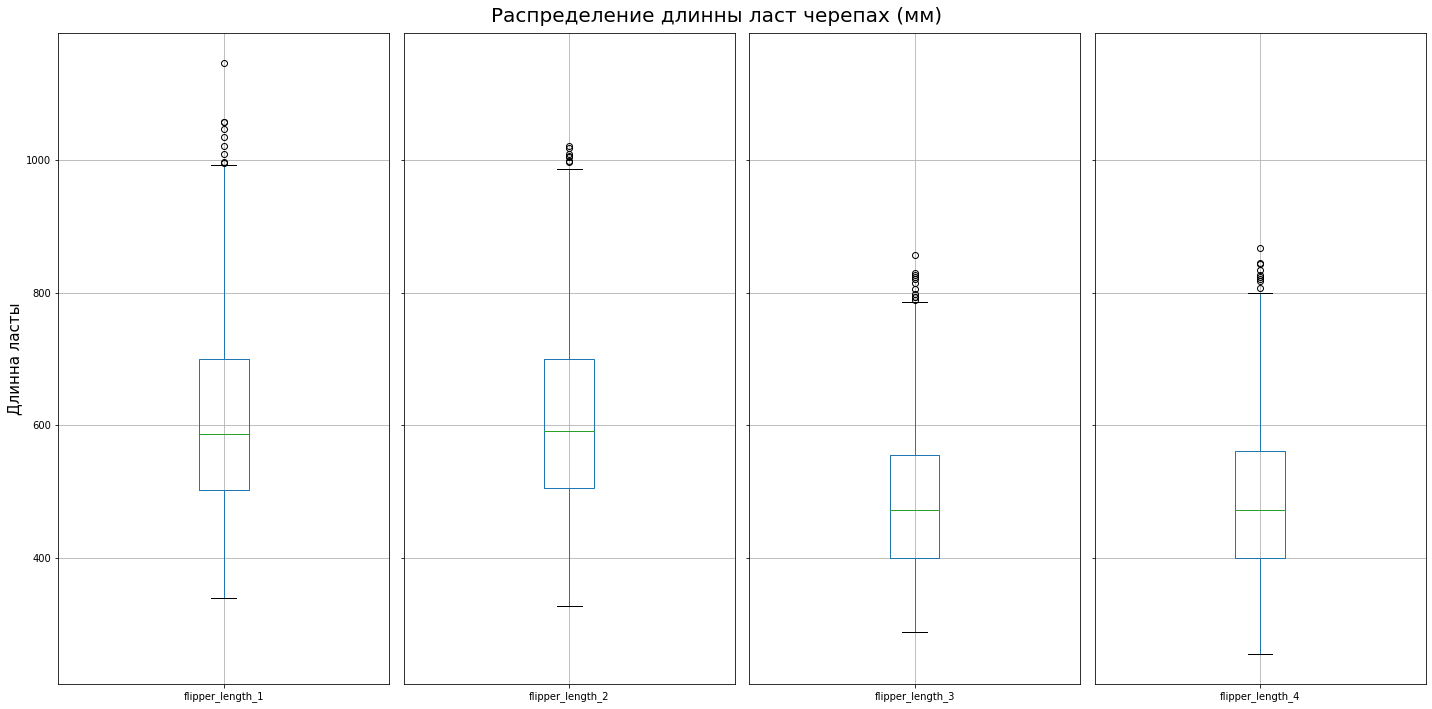

In [96]:
# Создаем ящики с усами для длинны каждой ласты черепахи
flipper_box_plot(
    dataframe = df_filtered_4_5,
    title = 'Распределение длинны ласт черепах (мм)',
    column_name = 'flipper_length',
    ylabel = 'Длинна ласты',
    figure_size = (20, 10))


* Данные о длинне каждой ласты распределены практический симметрично для всех ласт. Медианные значения, 25ый и 75ый квартили имеют очень близкие значение. 
* Среди данных есть выбросы. Однако, они всё ещё находятся в пределах разумного. Их тоже стоит оставить. Для того, чтобы установить то, что эти значения длинны ласт действительно явлюятся какой-то ошибкой нужно построить график совместного распределения.

<Figure size 288x288 with 0 Axes>

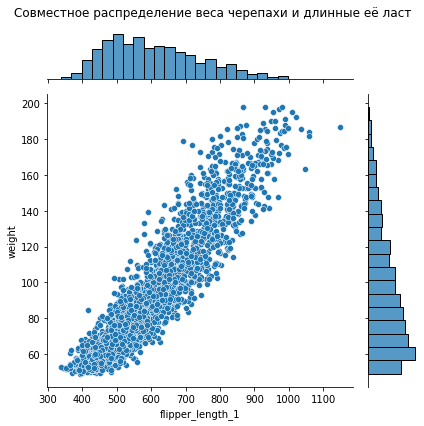

In [97]:
joint_plt(
    dataframe = df_filtered_4_5,
    x_col = 'flipper_length_1',
    title = 'Совместное распределение веса черепахи и длинные её ласт',
    figure_size = (4, 4))

<Figure size 288x288 with 0 Axes>

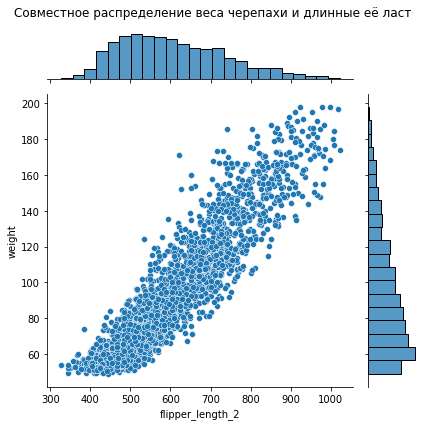

In [98]:
joint_plt(
    dataframe = df_filtered_4_5,
    x_col = 'flipper_length_2',
    title = 'Совместное распределение веса черепахи и длинные её ласт',
    figure_size = (4, 4))

* У самых тяжелых черепах также самые большие ласты. Высокие значения в этих данных не стоит считать выбросами.

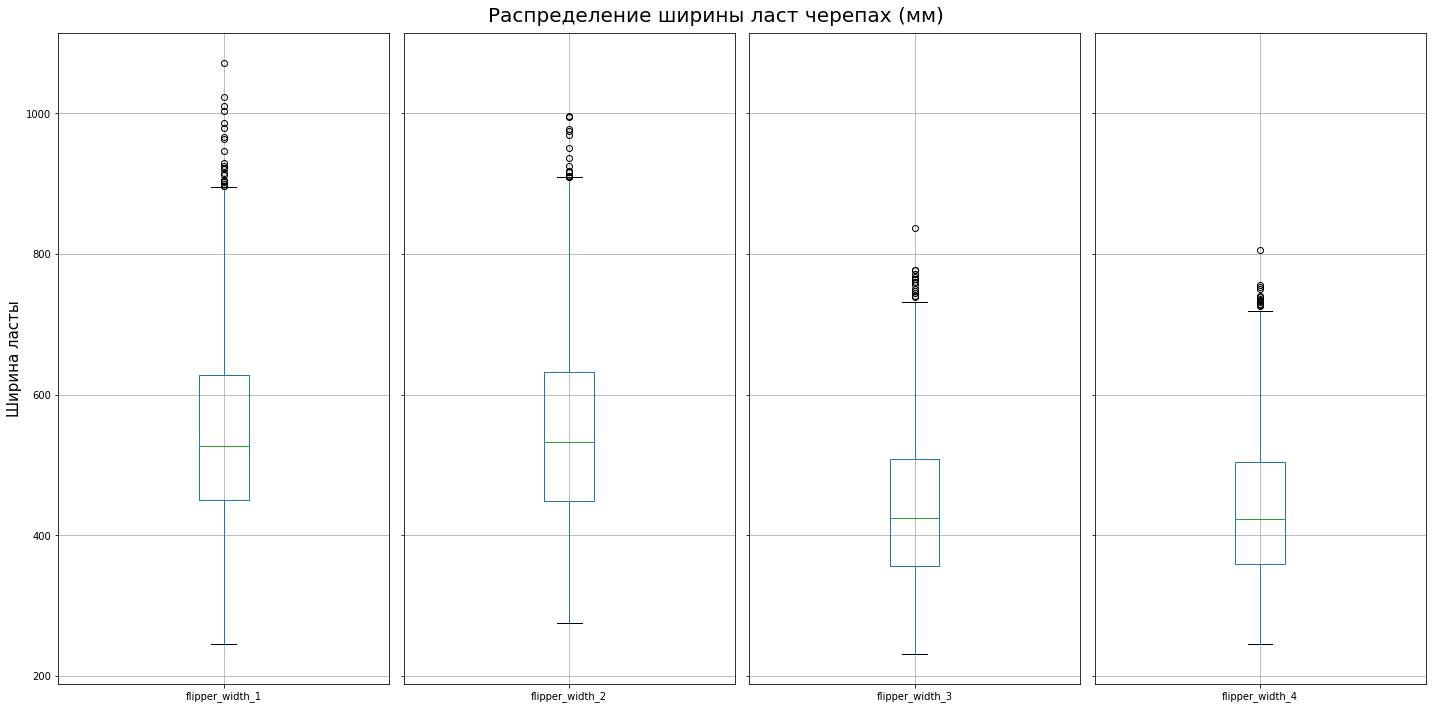

In [99]:
# Создаем ящики с усами для ширины каждой ласты черепахи
flipper_box_plot(
    dataframe = df_filtered_4_5,
    title = 'Распределение ширины ласт черепах (мм)',
    column_name = 'flipper_width',
    ylabel = 'Ширина ласты',
    figure_size = (20, 10))

* Здесь в данных также есть выбросы и распределение данных такое же как и с длинной ласт. Поэтому снова стоит проверить совместное распределение.

<Figure size 288x288 with 0 Axes>

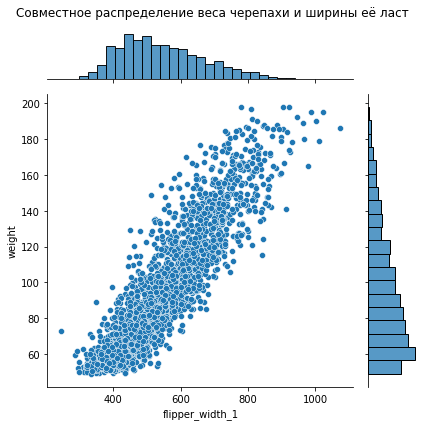

In [100]:
joint_plt(
    dataframe = df_filtered_4_5,
    x_col = 'flipper_width_1',
    title = 'Совместное распределение веса черепахи и ширины её ласт',
    figure_size = (4, 4))

<Figure size 288x288 with 0 Axes>

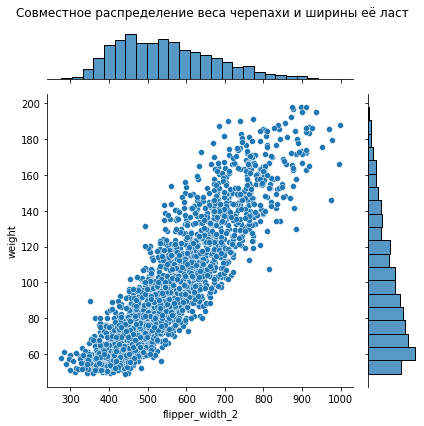

In [101]:
joint_plt(
    dataframe = df_filtered_4_5,
    x_col = 'flipper_width_2',
    title = 'Совместное распределение веса черепахи и ширины её ласт',
    figure_size = (4, 4))

* С шириной ласт всё в порядке. У тяжелых черепах широкие ласты. Можно переходить к следующим признакам.

In [102]:
circle_count_thresh = percentile_show(
    dataframe = df_filtered_4_5,
    column_name = 'circle_count',
    percentiles_list = percentiles_list,
    required_per = 0.95
    )

Значение перцентилей колонки 'circle_count' 
 0.01     48.0
0.05     57.0
0.10     61.0
0.25     70.0
0.50     80.0
0.75     91.0
0.90    102.0
0.95    109.0
0.99    122.0
Name: circle_count, dtype: float64


* В данной колонке все значения растут постепенно вне зависимости от перцентиля. Скорее всего, здесь нету каких-то выбросов, но стоит это проверить с помощью ящика с усами.

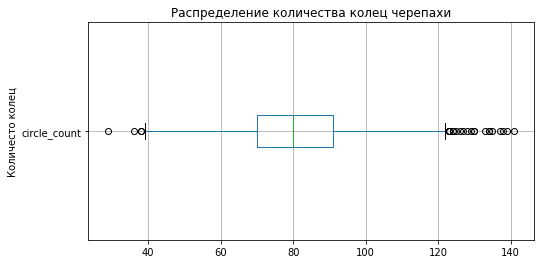

In [103]:
# Выводим распределение количества колец черепахи.
boxplot_plot(
    dataframe = df_filtered_4_5,
    column_name = 'circle_count',
    title = 'Распределение количества колец черепахи',
    ylabel = 'Количесто колец',
    figure_size = (8, 4)
)

* Всё же, здесь есть выбросы. Снова проверим совместное распределение.

<Figure size 288x288 with 0 Axes>

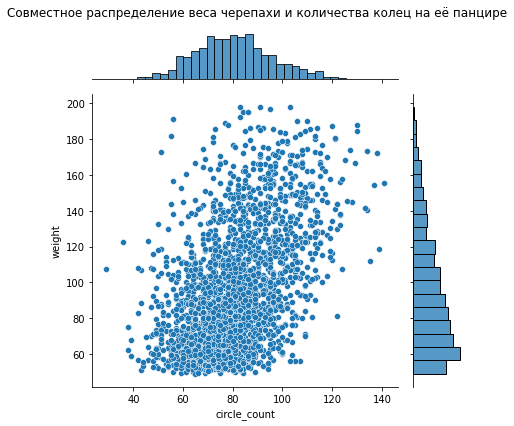

In [104]:
joint_plt(
    dataframe = df_filtered_4_5,
    x_col = 'circle_count',
    title = 'Совместное распределение веса черепахи и количества колец на её панцире',
    figure_size = (4, 4))

* Здесь данные очень непостоянные. Есть черепахи с малым количестом колец и большим весом и наоборот. Для безопасности лучше отфильтровать данные по 95му перцентилю. 

In [105]:
df_filtered_4_5 = df_filtered_4_5[df_filtered_4_5['circle_count'] <= circle_count_thresh]

In [106]:
# Считаем количество удаленных строк
deleted_rows_count = df_filtered.shape[0] - df_filtered_4_5.shape[0]
print(f'Количество удаленных строк: {deleted_rows_count}')
print(f'Итоговый размер датафрейма: {df_filtered_4_5.shape[0]}')

Количество удаленных строк: 460
Итоговый размер датафрейма: 2180


#### Промежуточный итог фильтраций

* Были проверены все признаки в датасете. В ходе анализа графиков совместного распределения удалось выяснить, что высокие значения во многих признаках черепахи нельзя считать выбросами. У всех черепах с большими габаритами ласт, головы, панциря и так далее также был большой вес. Однако, оказалось, что высокие значения в количестве колец явлюятся выбросами, поэтому было принято решение отфильтровать их на основе 95го перцентиля.
* В общей сложности было удалено 504 строк и в датафрейме осталось 2136 строк. 
* Также были удалены явные и неявные дубликаты в датафрейме. 

### Корреляция между разными признаками и целевой переменной
* Для того, чтобы оценить корреляцию между признаками черепахи и её весом можно сделать 2 вещи: построить график рассеяния, который позволит установить наличие корреляций, её харакитер и силу; Высчитать корреляционную матрицу и отсортировать признаки, с которыми целевая переменная коррелирует больше всего.
* Напишем 2 функций для этой цели.

#### Функций для изображения и подсчета взаимосвязи между признаками и целевой переменной

In [107]:
# Определяем функцию для построение графика рассеяния между признаком и целевой переменной
def plot_scatterplot(
    dataframe,
    column_name: str,
    title: str,
    xlabel: str,
    color = 'blue',
    edgecolor = 'black',
    dot_size = 50,
    figsize = (8, 6)
    ):

# Создаем график рассеивания с нужными параметрами
    dataframe.plot(
    kind = 'scatter', # Вид графика
    x = column_name, # Название колонки x
    y = 'weight', # Целевая переменная
    alpha = 0.7, # Прозрачность
    color = color, # Цвет точек
    edgecolor = edgecolor, # Цвет края точек
    s = dot_size, # Размер точек
    title = title, # Название графика
    xlabel = xlabel,
    figsize = figsize
    )
    

* В будущем надо будет проверить коллиниарность данных, поэтому в функции для подсчета корреляционной матрицы надо выполнить 2 задачи. Первая, если нам нужно просто корреляционная матрица, без внимания на целевую переменную, то тогда функция должна сделать тепловую карту для взаимосявзи признаков друг с другом. Это поможет обнаружить возможную мультиколлинеарность между признаками. Второе, если нам надо подсчитать корреляцию между целевой переменной и остальными признаками черепахи, то функцию должно будет построить тепловую карту только для целевой переменной.

In [108]:
# Определяем функцию для постороения тепловой карты корреляций между целевой переменной и другими признаками
def corr_matrix(
    dataframe,
    corr_columns: list,
    title: str,
    annotate = True,
    frmt = '.2f',
    linewidths = 0.5,
    cmap = 'viridis',
    figsize = (8, 6),
    column_of_int = None
    ):
    
    if column_of_int is None:
        # Удаляем целевую переменную из списка признаков, считаем корреляционную матрицу и извлекаем верхний треугольник 
        # матрицы.
        corr_cols = corr_columns.copy()
        corr_cols.remove('weight')
        corr_matrix = dataframe[corr_cols].corr(method = 'spearman')
        triangle = np.triu(corr_matrix)
        # Создаем тепловую карту нужного размера
        plt.figure(figsize = figsize)
        sns.heatmap(data = corr_matrix, annot = annotate, fmt = frmt, linewidths = linewidths, cmap = cmap, mask = triangle)
        
        # Даем графику название и показываем его
        plt.title(title)
        return plt.show()
    else:
        
        # Считаем корреляционную матрицу
        corr_matrix = dataframe[corr_columns].corr(method = 'spearman')
    
        # Создаем тепловую карту с нужным размером
        plt.figure(figsize = figsize)
    
        # Избираем из матрицы корреляций только интересующию нас колонку
        weight_heatmap = corr_matrix.loc[
            corr_matrix.index != column_of_int][[column_of_int]].sort_values(by = column_of_int, ascending = False)
        # Создаем на основе выбранной колонки тепловую карту
        sns.heatmap(data = weight_heatmap, annot = annotate, fmt = frmt, linewidths = linewidths, cmap = cmap)
    
        # Даем графику название и показываем его
        plt.title(title)
        return plt.show()

* Когда нужные функций, надо провести визуализацию возможной корреляций между признаками и целевой переменной. Для компактности будем делать визуализацию сразу по длине и ширине части черепахи (где уместно).

#### Изображение взаимосвязи между признаками и целевой переменной

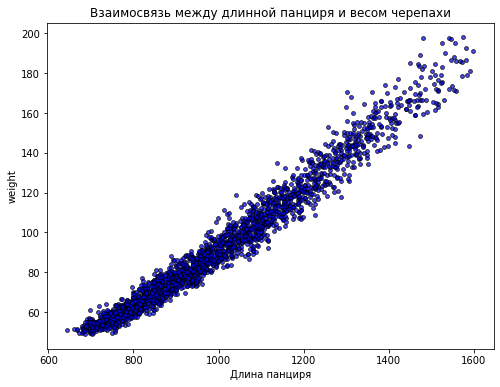

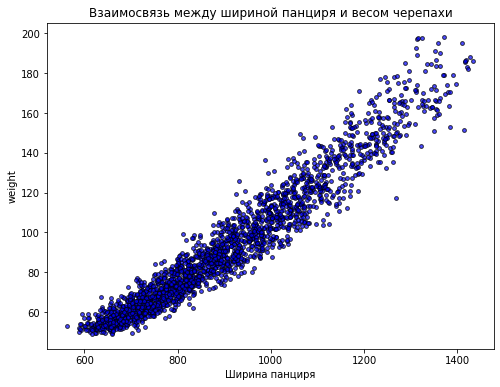

In [109]:
# Рисуем графики рассеивания между габаритами панциря и весом черепахи
plot_scatterplot(
    dataframe = df_filtered_4_5,
    column_name = 'shell_length',
    title = 'Взаимосвязь между длинной панциря и весом черепахи',
    xlabel = 'Длина панциря',
    dot_size = 15
    )
plot_scatterplot(
    dataframe = df_filtered_4_5,
    column_name = 'shell_width',
    title = 'Взаимосвязь между шириной панциря и весом черепахи',
    xlabel = 'Ширина панциря',
    dot_size = 15
    )

* Позитивная корреляция между габаритами панциря и весом черепахи четкая и сильная. Надо сохранить этот признак для обучения модели.

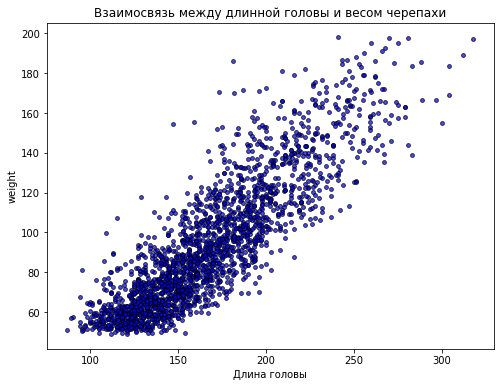

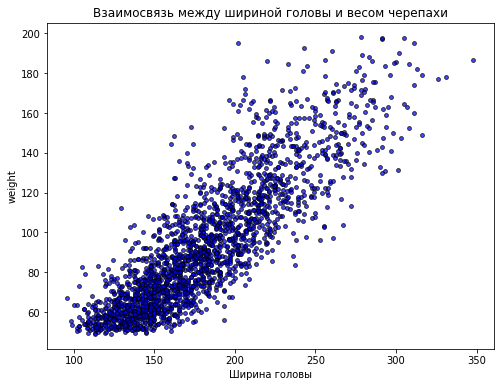

In [110]:
# Рисуем график рассеивания между габаритами головы черепахи и её весом
plot_scatterplot(
    dataframe = df_filtered_4_5,
    column_name = 'head_length',
    title = 'Взаимосвязь между длинной головы и весом черепахи',
    xlabel = 'Длина головы',
    dot_size = 15
    )
plot_scatterplot(
    dataframe = df_filtered_4_5,
    column_name = 'head_width',
    title = 'Взаимосвязь между шириной головы и весом черепахи',
    xlabel = 'Ширина головы',
    dot_size = 15
    )

* Между этими двумя признаками и целевой переменной также есть позитивная корреляция. Однако, она слабее по сравнению с габаритами панциря. Разброс точек здесь намного шире, что говорит о более слабой взаимосвязи с весом черепахи.
* В датасете имеется данные о габарите каждой ласты черепахи, поэтому будет компактнее написать функцию, которая будет выводить один большой график, где каждый подграфик рассеивания будет показывать взаимосвязь между длинной/шириной отдельной ласты и весом черепахи.

In [111]:
def mulp_scatterplot(
    dataframe,
    column_name: str,
    y_column: str,
    title: str,
    edgecolor = 'black',
    color = 'blue',
    dot_size = 50,
    alpha = 0.7,
    figure_size = (8, 6),
    col_num = 4,
    font_size = 15
    ):
    
    # Проверяем, что название колонок было передано правильно
    if (column_name == 'flipper_length' or column_name == 'flipper_width'):
        pass
    else:
        return 'Выбрано неправильное название столбца. Введите "flipper_length" либо "flipper_width"'
    
    # Создаем полотно для графика и передаем нужное количество подграфиков
    fig, axs = plt.subplots(nrows = 1, ncols = col_num, figsize = figure_size, sharey = True )
    
    # Создаем отдельный подграфик для каждой конечности черепахи
    for i in range(1, 5):
        
        # Передаем переменной название нужной нам колонки
        x_column_name = column_name + '_' + str(i)
        
        dataframe.plot(
            kind = 'scatter', # Вид графика
            x = x_column_name, # Название колонки x
            y = 'weight', # Целевая переменная
            alpha = 0.7, # Прозрачность
            color = color, # Цвет точек
            edgecolor = edgecolor, # Цвет края точек
            s = dot_size, # Размер точек 
            ax = axs[i-1] # Подграфик, где будет изображена взаимосвязь
            )
    
    
    # Передаем название графика и оси y
    fig.suptitle(title, size = font_size)
    plt.tight_layout()
    
    # Показываем график
    return plt.show()

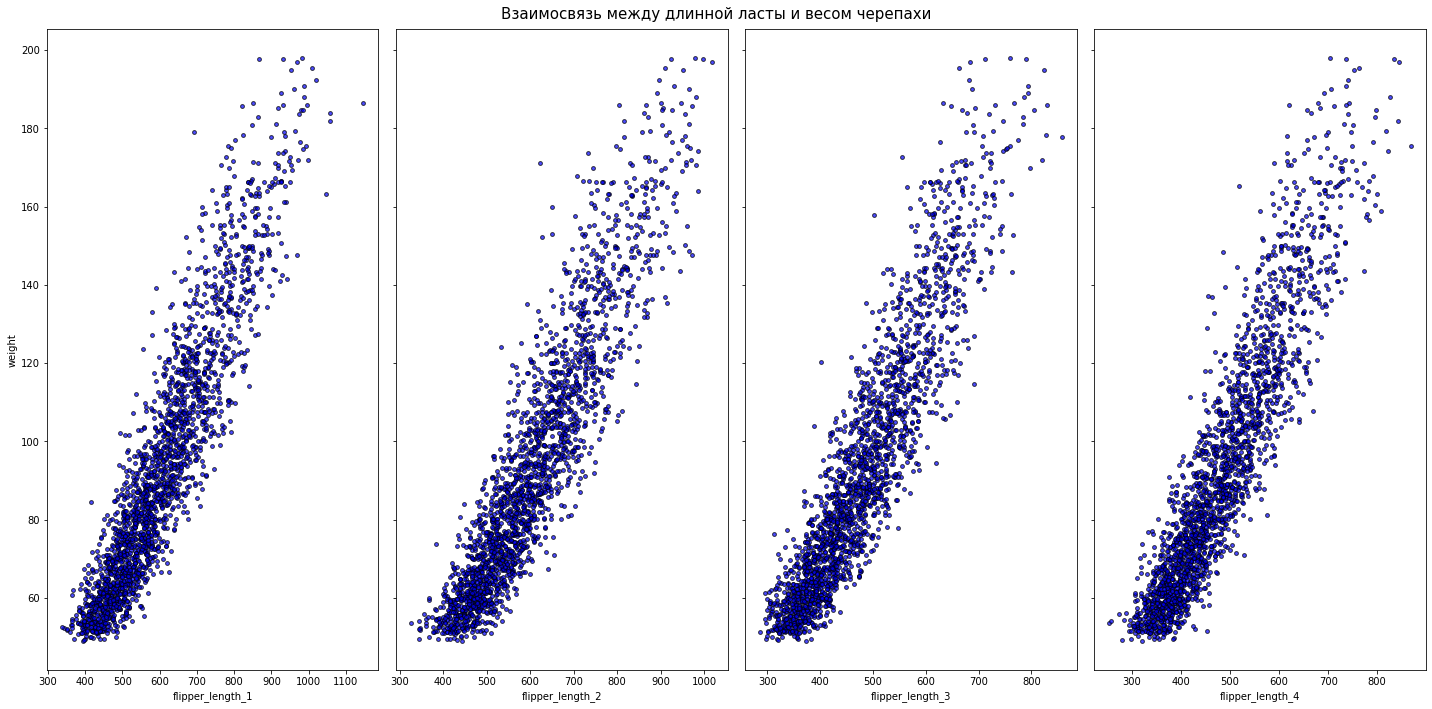

In [112]:
# Рисуем график рассеивания с подграфиком для каждой отдельной ласты
mulp_scatterplot(
    dataframe = df_filtered_4_5,
    column_name = 'flipper_length', # Длинна ласты
    y_column = 'weight',
    title = 'Взаимосвязь между длинной ласты и весом черепахи',
    figure_size = (20, 10),
    dot_size = 15
    )

* Подграфики четко показывают, что между длинной каждой ласты и весом черепахи есть сильная позитивная корреляций вне завимости от ласты. Все эти признаки надо оставить в датафрейме.

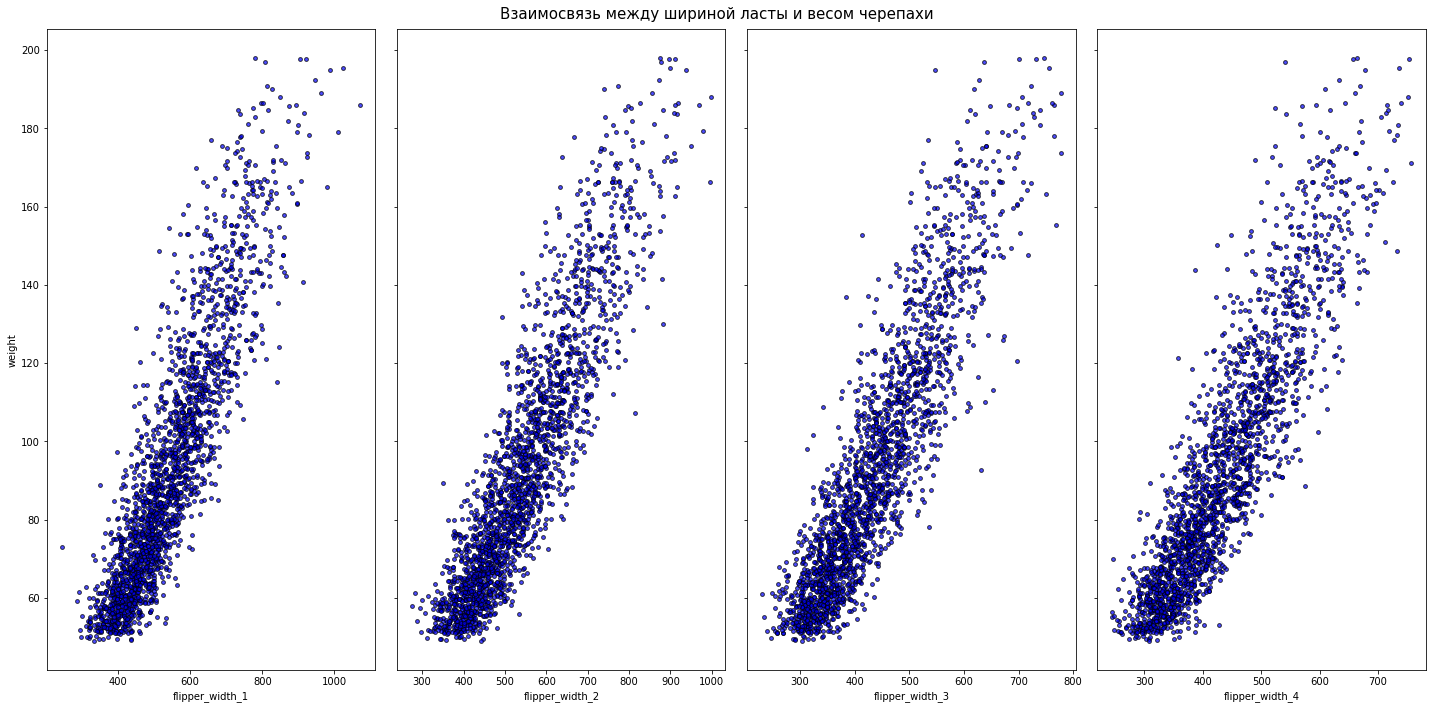

In [113]:
# Рисуем график рассеивания с подграфиком для каждой отдельной ласты
mulp_scatterplot(
    dataframe = df_filtered_4_5,
    column_name = 'flipper_width', # Ширина ласты
    y_column = 'weight',
    title = 'Взаимосвязь между шириной ласты и весом черепахи',
    figure_size = (20, 10),
    dot_size = 15
    )

* Ширина ласт показывает такую же отчетливую позитивную корреляцию с весом черепахи, как и длинна ласт. Эти признаки тоже надо оставить будет в датафрейме.

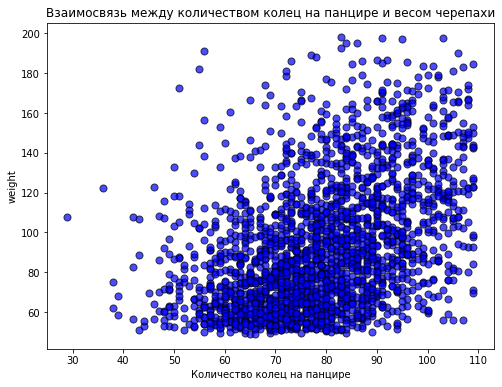

In [114]:
# Проверяем взаимосвязь между количеством колец на панцире и весом черепахи
plot_scatterplot(
    dataframe = df_filtered_4_5,
    column_name = 'circle_count',
    title = 'Взаимосвязь между количеством колец на панцире и весом черепахи',
    xlabel = 'Количество колец на панцире',
    )

* График показывает, что между количестом колец на панцире черепахи и её весом нету явной взаимосвязи. По мере увеличения колец на панцире черепахи, значения её веса растут незначительно. Здесь есть слабая взаимосвязь между весом черепахи, поэтому эти данные тоже стоит оставить.

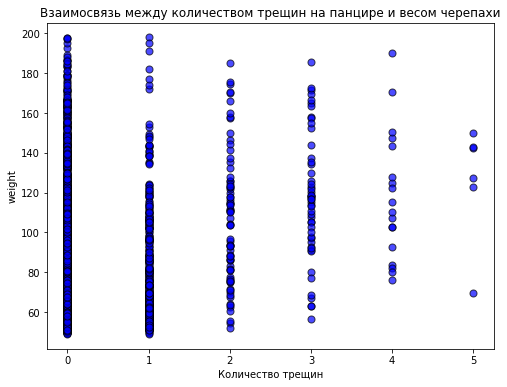

In [115]:
# Создаем график рассеивания между трещинами на панцире и весом черепахи
plot_scatterplot(
    dataframe = df_filtered_4_5,
    column_name = 'shell_crack',
    title = 'Взаимосвязь между количеством трещин на панцире и весом черепахи',
    xlabel = 'Количество трещин',
    )

* Количество трещин на панцире дискретно, поэтому оценить взаимосвязь между количеством трещин на панцире и её весом трудно. К тому же изначально в этих данных было очень много пропусков, поэтому для безопасности лучше убрать этот параметр из обучения модели. 

#### Корреляция между признаками и целевой переменной

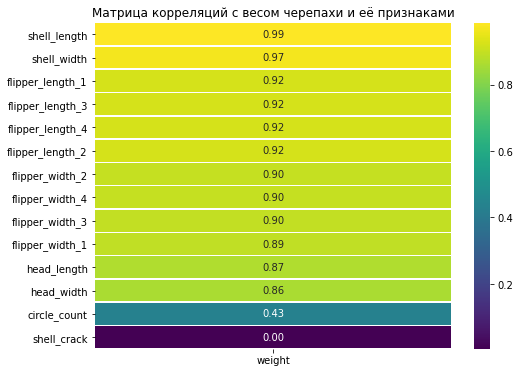

In [116]:
# Передаем переменной список интересующих столбцов
correlation_cols = [
        'shell_length', 
        'shell_width', 
        'head_length', 
        'head_width', 
        'flipper_length_1',
        'flipper_length_2',
        'flipper_length_3',
        'flipper_length_4',
        'flipper_width_1',
        'flipper_width_2',
        'flipper_width_3',
        'flipper_width_4',
        'circle_count',
        'shell_crack',
        'weight'
]

# Создаем тепловую карту корреляций между целевой переменной и интересующими признаками 
corr_matrix(
    dataframe = df_filtered_4_5,
    corr_columns = correlation_cols,
    column_of_int = 'weight',
    title = 'Матрица корреляций с весом черепахи и её признаками'
)


* Как и было выявлено при построений графиков, признаки, которые сильнее всего коррелируют с весом черепахи, это: габариты панциря и габариты ласт. И количество колец на панцире и количество трещин на нем очень слабо коррелируют с её весом. Поэтому от этих данных можно будет избавиться при обучений модели линейной регрессии.

#### Промежуточный вывод
* На первый взгляд, многие признаки в датасете оказались информативными – они все имели позитивную и однонаправленную корреляцию с целевой переменной. Их все было решено оставить для обучения модели. Кроме, количесто трещин на панцире. Тип этих данных и наличие большого количество пропусков в изначальном датасете подтолкнуло на исключение этого столбца из обучения модели.
* В целом, все признаки имеют очень сильную корреляцию с целевой переменной. Однако, почти все имеют схожий характер. У нас есть данные о длинне и ширине панциря, ласт, и головы. Длинна и ширина конечностей черепахи практический всегда пропорциональны друг-другу, поэтому есть большой риск наличия мультиколлинеарности между этими признаками. На следующем этапе ИАД надо будет проверить эту теорию и минимизировать её.
* Были обнаружены признаки, которые сильнее всего коррелируют с весом черепахи: габариты панциря, ласт и головы. Остальные признаки имеют намного более слабую связь.

### Изучение  мультиколлинеарности признаков

* Для проверки мультиколлинеарности между признаками можно воспользоваться той же функцией. Просто заменим значение аргумента `column_of_int`. Начнем по порядку, с признаков которые сильнее всего коррелируют с целевой переменной. И из столбцов надо удалить `circle_count` и `shell_crack`, потому что они не будут использоваться в обучений модели.

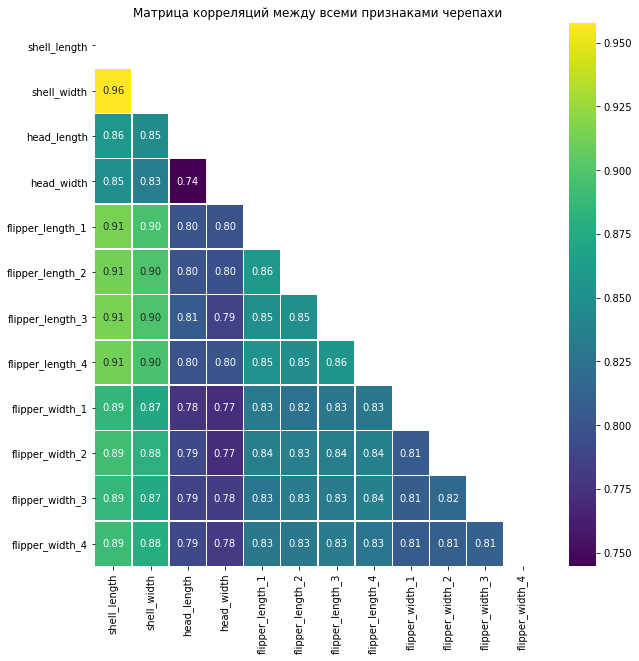

In [117]:
multi_corr_cols = [
        'shell_length', 
        'shell_width', 
        'head_length', 
        'head_width', 
        'flipper_length_1',
        'flipper_length_2',
        'flipper_length_3',
        'flipper_length_4',
        'flipper_width_1',
        'flipper_width_2',
        'flipper_width_3',
        'flipper_width_4',
        'weight'
]
corr_matrix(
    dataframe = df_filtered_4_5,
    corr_columns = multi_corr_cols,
    title = 'Матрица корреляций между всеми признаками черепахи',
    figsize = (10, 10)
)


* Как видно из тепловой карты, все признаки сильно коррелируют между собой. Минимальное значение коэффицента корреляций между любыми признаками не ниже 0.7. Это говорит о том, что в данных есть довольно сильная проблема мультиколлинеарности. В связи с этим при обучений модели лучше использовать Ridge регуляризацию. Она поможет бороться с мультиколлинеарностью признаков, уменьшая её влияние и делаю данные более устойчивыми к проблеме.

### Итог исследовательского анализа данных
1. В датафрейме были данные о разных видах черепах. Среди были отобраны данные только о виде `Chelonia mydas`. Далее, из датасета были удалены ненужные столбцы. Был проведен поиск явных и неяных дубликатов. И был проведен анализ распределение данных в нужных для обучения модели колонках. На основе построенных графиков и расчитанных перцентилей данные были отфильтрованы от выбросов. В общем сложности было удалено 506 строк и их итогове количество: 2134.
2. После обработки данных, была проведена оценка и иллюстрация корреляций признаков черепахи и целевой переменной – веса. Были обнаружены признаки, которые сильнее всего коррелировали с весом черепахи и были обнаружены признаки, которые коррелировали её весом меньше всего. Было принято решение исключить только один столбец – `shell_crack`, так как изначально в этой колонке было пропусков и она хранит в себе только дискретные значения.
3. После нахождение признаков с самой высокой корреляцией, была проведена оценка проблемы мультиколлинеарности между признаками. В ходе него было выяснено, что признаки сильно коррелирует между собой и было принято решение использовать Ridge регуляризацию для минимизаций данной проблемы.

## Предобработка данных

1. Разделите данные на выборки: обучающую (60%), валидационную (20%) и тестовую (20%). В реальных проектах стараются писать код предобработки так, чтобы предотвратить утечку данных. Это проще сделать, если сразу поделить данные.
2. Обработайте пропуски. При необходимости заполните их средними (медианными) значениями. Рассчитайте заполнитель только по обучающей выборке: это ещё одно правило для предотвращения утечки.
3. Напишите функцию для стандартизации признаков. Расчёт параметров масштабирования делайте только по обучающей выборке, чтобы не дать утечке ни малейшего шанса.
4. Напишите функцию для нормализации признаков.
5. Подготовьте несколько датасетов из трёх выборок каждый для дальнейшего обучения моделей с разным способом масштабирования: без масштабирования, с нормализацией, со стандартизацией.

### Деление данных на выборки и обработка пропусков

In [118]:
# Извлекаем из данных признаки и значения целевой переменной
X = df_filtered_4_5.drop(columns = ['weight', 'shell_crack'])
y = df_filtered_4_5['weight']

# Делим данные на выборки
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    shuffle = True,
    random_state = 42
)
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size =0.25,
    shuffle = True,
    random_state = 42
)

* Пропуски уже были обработаны в предыдущем этапе. Можно сразу переходить к масштабированию признаков в обучающей выборке.

### Масштабирование признаков 

In [119]:
# Определяем функцию для масштабизаций признаков
def scale_data(X_train, X_val, X_test, method='standard'):
    # Метод: стандартизация
    if method == 'standard':
        mean = X_train.mean() # ваш код здесь
        std = X_train.std() # ваш код здесь
        X_train_scaled = (X_train - mean) / std # ваш код здесь
        X_val_scaled = (X_val - mean) / std # ваш код здесь
        X_test_scaled = (X_test - mean) / std # ваш код здесь
    # Метод: Мин-Макс
    elif method == 'minmax':
        min_val = X_train.min() # ваш код здесь
        max_val = X_train.max()# ваш код здесь
        X_train_scaled = (X_train - min_val) / (max_val - min_val) # ваш код здесь
        X_val_scaled = (X_val - min_val) / (max_val - min_val) # ваш код здесь
        X_test_scaled = (X_test - min_val) / (max_val - min_val) # ваш код здесь
    else:
        raise ValueError("Неверный метод масштабирования. Используйте 'standard' или 'minmax'.")
    return X_train_scaled, X_val_scaled, X_test_scaled

* ИАД показал, что данные в датасете распределены неравномерно. Целевая переменная слегка ассиметричная: значение смещены в сторону больших значений. К тому же, мы оставили в данных большие и маленькие значения признаков, потому что они не являются выбросами. Поэтому в нашем случае лучше использовать стандартизацию для масштабирование признаков. Данный метод подходит в случаях, когда у нас есть большие и маленькие значения в датасете и нам надо сохранить взаимосвязь между признаками.

### Подготока датасетов: с нормализацией, со стандартизацией, без изменений.

In [120]:
# Масштабируем признаки во всех выборках
X_train_normal, X_val_normal, X_test_normal = scale_data(X_train, X_val, X_test)
X_train_standard, X_val_standard, X_test_standard = scale_data(X_train, X_val, X_test, method = 'minmax')

## Обучение моделей

1. Постройте базовую модель (дамми), с которой будете сравнивать все остальные. Если они будут хуже базовой по качеству, это будет означать, что при обучении что-то пошло не так. Пример дамми: модель, которая всегда предсказывает среднее значение целевой переменной из обучающей выборки.
2. Обучите несколько архитектур линейных моделей. Они могут различаться по ряду черт: набором отобранных признаков, масштабом признаков, установленными гиперпараметрами, функциями потерь. Попробуйте обучить следующие модели:
   - `LinearRegression`;
   - `Lasso` (L1-регуляризация);
   - `Ridge` (L2-регуляризация);
   - `SGDRegressor`.
   
   Обязательно попробуйте модели с разными значениями гиперпараметра `loss`.
- **Бонусное задание.** Подумайте, можно ли улучшить модели за счёт создания новых признаков: например, умножив длину ласт на ширину. Проверьте, усилится ли корреляция нового признака с целевой переменной, возрастёт ли благодаря ему качество модели.
3. Сформируйте итоговую таблицу с результатами моделей. Это удобно сделать в виде датафрейма pandas. Включите в таблицу следующие столбцы:
   - Название модели.
   - Название датасета — оно должно указывать на то, какой способ масштабирования использовался при подготовке данных.
   - Метрики качества, рассчитанные на валидационной выборке. Основная метрика — MAE, дополнительные — MSE, R², MAPE и прочие.

### Базовая модель линейной регрессий 
* В качестве базовой модели можно использовать `dummy_model` из библиотеки `sklearn` и сравнивать последующие модели с ней.

In [154]:
from sklearn.dummy import DummyRegressor

# Инициализируем базовую модель и обучаем её
dummy_model = DummyRegressor(strategy = 'mean')
dummy_model.fit(X_train, y_train)
y_pred_dummy_train = dummy_model.predict(X_train)
y_pred_dummy_val = dummy_model.predict(X_val)

### Обучение моделей с разными параметрами
* Для данной задачи лучше написать две функций: функция для обучения модели и функция для расчета метрик качества.

In [139]:
# ––ФУНКЦИЯ ДЛЯ ОБУЧЕНИЯ МОДЕЛЬ––
def linear_model_train(
    learn_type: str,
    loss_function: str,
    alpha: float,
    X_train,
    y_train,
    X_val,
    X_test
    ):
    # Выбираем модель в зависимости от значения learn_type
    if learn_type == 'Ridge':
        model = Ridge(alpha = alpha)
    
    elif learn_type == 'Lasso':
        model = Lasso(alpha = alpha)
    
    elif learn_type == 'LinearRegression':
        model = LinearRegression()
    
    elif learn_type == 'SGDRegressor':
        model = SGDRegressor(alpha = alpha, loss = loss_function, random_state = 42, max_iter = 1000)
        
    else: 
        raise ValueError(
            'Введено неправильное значение для learn_type. '
            'Используйте: "Ridge", "Lasso", "LinearRegression", "SGDRegressor".'
        )
    
    # Обучаем выбранную модель на тренировочной выборке 
    model.fit(X_train, y_train)
    
    # Делаем предсказания на тренировочной, валидационной и тестировочной выборках 
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)
    
    # Возвращаем модель и предсказания
    return model, y_train_pred, y_val_pred, y_test_pred
    

In [140]:
# ––ФУНКЦИЯ ДЛЯ РАСЧЕТА МЕТРИК––
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred) 
    r2 = r2_score(y_true, y_pred) 
    return {
            'MAE': round(mae, 2),
            'MSE': round(mse, 2),
            'RMSE': round(rmse, 2),
            'MAPE': round(mape * 100, 2),
            'R2': round(r2, 3)}

In [170]:
# Сохраняем метрики базовой модели в словарь, далее отфильтруем итоговую таблицу на их основе
dummy_train_metric = calculate_metrics(y_train, y_pred_dummy_train)

dummy_metrics = {
    'train_MAE': dummy_train_metric['MAE'],
    'train_MSE': dummy_train_metric['MSE'],
    'train_RMSE': dummy_train_metric['RMSE'],
    'train_MAPE': dummy_train_metric['MAPE'],
    'train_R2': dummy_train_metric['R2'],
    'val_MAE': dummy_val_metric['MAE'],
    'val_MSE': dummy_val_metric['MSE'],
    'val_RMSE': dummy_val_metric['RMSE'],
    'val_MAPE': dummy_val_metric['MAPE'],
    'val_R2': dummy_val_metric['R2']
    }

* По заданию надо будет обучить разные модели на основе разных выборок и гиперпараметров. Для компактности можно создать 2 списками со словарями. Первый словарь будет заключать в себе названия выборки с/без регуляризацией. Второй будет заключать в себе названия моделей, их типы, гиперпараметры.

In [151]:
# Словарь для выборок в формате:
# dataset_name – название выборки
# X_train – тренировочная выборка
# X_val – валидационная выборка
# X_test – тестировачная выборка

datasets = [
    {
        'dataset_name': 'No scaling', # 
        'X_train': X_train,
        'X_val': X_val,
        'X_test': X_test
    },
    {
        'dataset_name': 'Normalization',
        'X_train': X_train_normal,
        'X_val': X_val_normal,
        'X_test': X_test_normal
    },
    {
        'dataset_name': 'MinMax',
        'X_train': X_train_standard,
        'X_val': X_val_standard,
        'X_test': X_test_standard
    }
]

# Словарь с названиями и гиперепараметрами моделей
model_configs = [
    {
        'model_name': 'LinearRegression',
        'learn_type': 'LinearRegression',
        'alphas': [None],
        'loss_functions': [None]
    },
    {
        'model_name': 'Ridge',
        'learn_type': 'Ridge',
        'alphas': [0.01, 0.1, 1, 10, 100],
        'loss_functions': [None]
    },
    {
        'model_name': 'Lasso',
        'learn_type': 'Lasso',
        'alphas': [0.001, 0.01, 0.1, 1, 10],
        'loss_functions': [None]
    },
    {
        'model_name': 'SGDRegressor',
        'learn_type': 'SGDRegressor',
        'alphas': [0.0001, 0.001, 0.01, 0.1],
        'loss_functions': ['squared_loss', 'epsilon_insensitive']
    }
]

* После создания нужных списков, можно начать цикл обучения. Цикл обучения будет работать следующим образом: сперва создаем список, в котором мы будем хранить результаты обучения модели. Потом, начинаем цикл, который извлекает из словаря `datasets` 3 выборки данных, потом начинаем второй цикл, который извлекает параметры из `model_configs`. Дальше, вызывает функцию `linear_model_train` и `calculate_metrics` для получения предсказаний модели и высчета метрик на их основе и сохраняет результат в список `results`. 

In [163]:
# Создаем пустой список для результатов моделей
results = []

# Проходим по каждому варианту датасета
for dataset in datasets:
    
    dataset_name = dataset['dataset_name']
    X_tr = dataset['X_train']
    X_v = dataset['X_val']
    X_te = dataset['X_test']
    
    # Проходим по каждой модели
    for config in model_configs:
        
        model_name = config['model_name']
        learn_type = config['learn_type']
        
        # Проходим по разным значениям alpha
        for alpha in config['alphas']:
            
            # Проходим по разным функциям потерь
            for loss_function in config['loss_functions']:
                
                # Для LinearRegression alpha и loss_function не используются
                # Поэтому задаем им технические значения, чтобы функция не ломалась
                current_alpha = 0 if alpha is None else alpha
                current_loss = 'squared_loss' if loss_function is None else loss_function
                
                # Обучаем модель и получаем предсказания
                model, y_train_pred, y_val_pred, y_test_pred = linear_model_train(
                    learn_type=learn_type,
                    loss_function=current_loss,
                    alpha=current_alpha,
                    X_train=X_tr,
                    y_train=y_train,
                    X_val=X_v,
                    X_test=X_te
                )
                
                # Считаем метрики на тренировочной выборке
                train_metrics = calculate_metrics(y_train, y_train_pred)
                
                # Считаем метрики на валидационной выборке
                val_metrics = calculate_metrics(y_val, y_val_pred)
                
                # Сохраняем результат в список
                results.append({
                    'model': model_name,
                    'dataset': dataset_name,
                    'alpha': alpha,
                    'loss_function': loss_function,
                    
                    # Метрики на train
                    'train_MAE': train_metrics['MAE'],
                    'train_MSE': train_metrics['MSE'],
                    'train_RMSE': train_metrics['RMSE'],
                    'train_MAPE': train_metrics['MAPE'],
                    'train_R2': train_metrics['R2'],
                    
                    # Метрики на validation
                    'val_MAE': val_metrics['MAE'],
                    'val_MSE': val_metrics['MSE'],
                    'val_RMSE': val_metrics['RMSE'],
                    'val_MAPE': val_metrics['MAPE'],
                    'val_R2': val_metrics['R2']
                })

По итогу, у нас выходит список, который состоит из словарей следующего содержания:

* `model` – Название модели
* `dataset` – Название выборки, на которой обучалась модель
* `alpha` – коэффициент регуляризаций (где применимо)
* `loss_function` – лосс функция (где применимо)
* `train_MAE` – средняя абсолютная ошибка тренировочной выборки
* `train_MSE` – средняя квадратичная ошибка тренировочной выборки
* `train-RMSE` – средняя квадратичная ошибка тренировочной выборки под корнем
* `train_R2` – коэффициент детерминаций тренировочной выборки

* `val_MAE` – средняя абсолютная ошибка валидационной выборки
* `val_MSE` – средняя квадратичная ошибка валидационной выборки
* `val_RMSE` – средняя квадратичная ошибка валидационной выборки
* `val_R2` – коэффициент детерминаций валидационной выборки

### Итоговая таблица с метриками качества моделей линейной регрессий

In [173]:
# Создаем на основе полученных результатов датафрейм
results_df = pd.DataFrame(results)

# Выбираем столбцы, которые надо будет отфильтровать
metrics_to_filter = [
    'train_MAE', 
    'train_MSE', 
    'train_RMSE', 
    'train_MAPE', 
    'val_MAE', 
    'val_MSE', 
    'val_RMSE', 
    'val_MAPE'
]

coefs_to_filter = [
    'train_R2',
    'val_R2'
]
        
# Фильтруем данные в датафрейме: избавляемся от всех строк, где метрики ниже чем у базовой модели
for metrics in metrics_to_filter:
    results_df = results_df[results_df[metrics] < dummy_metrics[metrics]]
for coef in coefs_to_filter:
    results_df = results_df[results_df[coef] > dummy_metrics[coef]]

### Промежуточный итог на основе обучения моделей

1. В ходе обучения моделей была сделана базовая модель `dummy_model` и написаны функций для компактного обучения разных моделей и рассчета метрик их качества. Были рассчитаны метрики базовой модели для оценки качества дальнейших моделей.
2. Были обучены модели линейной регрессий различного типа: Lasso, Ridge, LinearRegression, SGDRegressor с разными гиперпараметрами для поиска самой оптимальной. С помощью специальной функций, были рассчитаны метрики их качества, которые были сохранены в список из словарей `results`. 
3. Была сделана таблица с результами каждой модели.

## Сравнение моделей на валидационной выборке

1. Сравните построенные модели по метрикам на валидационной выборке. Удалось ли существенно улучшить результат базовой модели?
2. Выберите лучшую модель по основной метрике на валидационной выборке. Не заглядывайте в метрики на тестовой выборке раньше времени. Тестовая выборка не используется для обучения моделей, подбора гиперпараметров и сравнения моделей с разными значениями.
3. Напишите выводы о том, какая из моделей обладает лучшим качеством. Именно её одну далее нужно проверить на тестовой выборке для итоговой оценки.

In [174]:
# Сортируем результаты моделей на основе величины ошибки MAE и коэффициента R^2
sorted_results_df = results_df.sort_values(by = ['val_MAE'], ascending = True)

# Выводим топ-10 моделей с самым низкой ошибкой MAE
sorted_results_df.head(10)

,model,dataset,alpha,loss_function,train_MAE,train_MSE,train_RMSE,train_MAPE,train_R2,val_MAE,val_MSE,val_RMSE,val_MAPE,val_R2
28,Lasso,Normalization,1.000,None,3.38,20.44,4.52,3.64,0.980,3.49,23.21,4.82,3.69,0.980
44,Lasso,MinMax,0.001,None,3.39,19.10,4.37,3.81,0.981,3.51,21.32,4.62,3.96,0.982
45,Lasso,MinMax,0.010,None,3.39,19.11,4.37,3.79,0.981,3.51,21.33,4.62,3.94,0.982
27,Lasso,Normalization,0.100,None,3.38,19.11,4.37,3.78,0.981,3.51,21.38,4.62,3.92,0.982
26,Lasso,Normalization,0.010,None,3.39,19.10,4.37,3.81,0.981,3.51,21.32,4.62,3.95,0.982
0,LinearRegression,No scaling,NaN,None,3.39,19.10,4.37,3.81,0.981,3.52,21.32,4.62,3.96,0.982
40,Ridge,MinMax,0.100,None,3.39,19.10,4.37,3.81,0.981,3.52,21.37,4.62,3.96,0.982
25,Lasso,Normalization,0.001,None,3.39,19.10,4.37,3.81,0.981,3.52,21.32,4.62,3.96,0.982
46,Lasso,MinMax,0.100,None,3.40,20.13,4.49,3.74,0.980,3.52,22.34,4.73,3.83,0.981
39,Ridge,MinMax,0.010,None,3.39,19.10,4.37,3.81,0.981,3.52,21.33,4.62,3.96,0.982


In [199]:
# Метрики базовой модели
dummy_metrics

{'train_MAE': 25.83,
 'train_MSE': 1001.79,
 'train_RMSE': 31.65,
 'train_MAPE': 29.85,
 'train_R2': 0.0,
 'val_MAE': 28.2,
 'val_MSE': 1189.62,
 'val_RMSE': 34.49,
 'val_MAPE': 32.78,
 'val_R2': -0.0}

Модель с самой низкой ошибкой типа `MAE` на валидационной выборке имеет следующие характеристики:
* `model` – Lasso.
* `dataset` – Normalization.
* `alpha` – 1.0
* `loss_function` – Нету. К модели линейной регрессии с регуляризацией Lasso лосс функция не применима.
* `train_MAE` – 3.38, `val_MAE` – 3.49. Рост ошибки типа MAE является незначительным. Модель показывает стабильный результат на основе метрик валидационной выборки
* Остальные метрики по типу `MSE`, `RMSE`, `MAPE`, `R2` также стабильны. Их значения растут лишь незначительно на валидационной выборке. В плане размеров ошибок, модель показывает усточивый результат.
* `train_R2` – 0.980, `val_R2` – 0.980. Значения коэффициентов очень близки друг-другу.

Это является существенным улучшением по сравнению с базовой моделью. 
* Ошибка `MAE` на валидационной выборке у базовой модели была 28.2 Модель с самым низким показателем ошибки `MAE` уменьшила данную ошибку почти в 10 раз. Такая же ситуация и с другими типами ошибок. Они существенно меньше чем у базовой модели.
* Коэффициент $R^2$ у базовой модели 0.0, в то время как у самой лучшей модели он 0.980. Эти факты указывают на то, что лучшая модель линейной регрессий смогла уловить взаимосвязь между данными.

## Проверка лучшей модели на тестовой выборке

1. Проверьте метрики лучшей модели на тестовой выборке.
2. Узнайте, есть ли признаки переобучения лучшей модели.
3. Определите, соответствует ли модель требованиям заказчика. Объясните, можно ли её рекомендовать к внедрению.

In [198]:
# Иницилизируем модель, которая выдала самый лучший результат. 
best_model = Lasso(alpha = 1)
# Обучаем данные на нужной выборке: выборке с нормализацией
best_model.fit(X_train_normal, y_train)
y_test_pred = best_model.predict(X_test_normal)
calculate_metrics(y_test, y_test_pred)

{'MAE': 3.51, 'MSE': 23.44, 'RMSE': 4.84, 'MAPE': 3.73, 'R2': 0.98}

Проверка переобучения модели:
* На основе тестовой выборки были высчитаны основные метрики качества модели. Высчитанные значения не сильно отличаются от метрик высчитанных на основе валидационной выборки. Значение лишь незначительно выросли: `val_MAE` – 3.49, `test_MAE` – 3.51; `val_MSE` – 23.31, `test_MSE` – 23.44; `val_RMSE` – 4.82, `test_RMSE` – 4.84; `val_MAPE` – 3.69, `test_MAPE` – 3.73; `val_R2` – 0.980, `test_R2` – 0.98. 
* Ошибка `MAE` в тестовой выборке оказалась ниже 5 – 3.51; `MAPE` – 3.73%, что говорит о низкой процентной ошибке, большинство предсказанных значений слегка отклнояются от истинных; $R^2$ – 0.98, что выше чем минимальный порог – 0.97; Выборка данных была разделена верно – 20% от всех наблюдений была определено в тестовую выборку;  
* На основе высокого значения $R^2$ и значения ошибок, которые намного ниже допустимых, можно прийти к выводу то, что модель обучилась хорошо и она смогла уловить взаимосвязь признаков и целевой переменной. На этой основе можно рекомендовать модель к внедрению.

## Оценка важности признаков

1. Оцените важность признаков по абсолютным значениям весов лучшей модели.
2. Напишите, какие признаки стали для модели более важными. Объясните, согласны ли вы с таким результатом?

In [207]:
# Выводим название колонки и её вес в линейной регрессий
for column_name, weight in zip(df_filtered_4_5, best_model.coef_):
    print('Вес признака {col_name}: {wght:.2f}'.format(col_name = column_name, wght = weight))

Вес признака shell_length: 12.81
Вес признака shell_width: 5.88
Вес признака head_length: 1.09
Вес признака head_width: 0.79
Вес признака flipper_length_1: 2.09
Вес признака flipper_width_1: 1.21
Вес признака flipper_length_2: 1.51
Вес признака flipper_width_2: 1.06
Вес признака flipper_length_3: 1.36
Вес признака flipper_width_3: 1.27
Вес признака flipper_length_4: 1.44
Вес признака flipper_width_4: 1.25
Вес признака circle_count: 0.00


* Признаки с самым большими весами это: `shell_length` – 12.81, `shell_width` – 5.88. Все остальные веса намного меньше по сравнению с этими двумя. Данный факт соотносится с матрицей корреляций, которая была сделана раньше. Эти два признака сильнее всего коррелировали с целевой переменной, но в тоже время коэффициент корреляций остальных признаков был близок к таковым у `shell_length` и `shell_width`. 
* Скорее всего данный факт можно объяснить тем, что в данных была проблема мультиколлинеарности: все признаки сильно коррелировали между собой. Это подтолкнуло модель `Lasso`, которая была выбрана, постараться минизировать данную проблему и поэтому она сильно занизила веса всех остальных признаков. 

## Функция для прогнозирования веса черепахи

* Напишите на Python функцию, которая будет прогнозировать массу черепахи по заданным параметрам с учётом коэффициентов лучшей модели (свойство `coef_`) и смещения (свойство `intercept_`).
* Если вы столкнётесь с трудностями при написании функции, то представьте, что обращаетесь к старшему коллеге с просьбой помочь, и составьте задание для её написания. Подробно опишите логику, по которой рассчитывается масса черепахи, и укажите, как именно должны происходить расчёты.

In [211]:
"""
        Функция для предсказания массы черепахи. В функцию надо передать название обученной модели и список, который 
    будет содержать себе информацию о размерах черепахи строго в данном порядке: shell_length, shell_width,
    head_length, head_width, flipper_length_1, flipper_width_1, flipper_length_2, flipper_width_2,
    flipper_length_3, flipper_width_3, flipper_length_4, flipper_width_4, circle_count. 
        Далее, функция извлекает из модели значение смещение – bias и массив весов признаков. В цикле функций, каждый 
    признак умножается на свой соответствующий вес и добавляется к изначальной массой черепахи (в качестве него было 
    значение смещение).
        Функция возвращает прогноз массы черепахи.
"""
def predict_mass(
    model, # Название модели
    turtle_features: list # Список со значениями признаков черепахи. 
    ):
    
    bias = model.intercept_ # Смещение
    weights = model.coef_ # Массив весов
    turtle_mass = bias # Начальная масса черепахи
    
    for feature, weight in zip(turtle_features, weights): 
        turtle_mass += feature * weights
        
    return turtle_mass 

## Общие выводы и рекомендации по дальнейшей работе

Напишите общие выводы и рекомендации по дальнейшей работе. Ответьте на вопросы:
  - Какие модели изучены?
  - Какие результаты получены?
  - Рекомендуется ли итоговая модель к внедрению?
  - Какая архитектура и способ обработки признаков показали себя лучше всего? Какие у них показатели метрик?
  - Какие признаки наиболее важны для модели?
  - Есть ли перспективы у обучения этой или других моделей для предсказания массы других видов черепах?
  - При наличии добавьте сюда свои предложения по дальнейшему развитию проекта.

<b> Изученные модели </b>
* В ходе обучения модели линейной регрессий были использованы: `LinearRegression`, `Lasso`, `Ridge`, `SGDRegressor` с разными гиперпараметрами. В ходе изучения моделей было выяснено, что модель `Lasso` оказалась самой лучшей для данного датасета, так признаки сильно коррелировали между собой.

<b> Результаты </b>
* Изначальны датасет был избавлен всех не морфологических признаков. Далее, среди всех видов черепах были избраны нужные – `Chelonia mydas`. После датафрейм был очищен от явных/не явных дубликатов и выбросы в данных, которые не коррелировали с большим весом черепахи были отфильтрованы. Большинство высоких значений было принято оставить, потому что они были у черепах с большим весом. Если бы они были удалены это бы исказило картину, потому что в датасете стало бы меньше черепах с большим весом. Однако, в данных были ошибки и они были успешно удалены. 
* В результате работы была выялена самая лучшая модель линейной регрессий. `Lasso`-модель обученная на нормализированной выборке с гиперпараметром `alpha` = 1. Она показала самое низкое значение ошибки `MAE` и один из самых высоких коэффицентов $R^2$. Данная модель оказалась очень точной, со среднем ошибкой в 3.7%. Данная модель помогла найти признаки с самыми большими весами. Но из-за мультиколлинеарности признаков они не точно отражают их важность.

<b> Внедрение модели </b>
* Значения метрик модели оказались намного лучше пороговых значений и она не показала никаких признаков переобучения или недообучения, поэтому можно рекомендовать итоговую модель к внедрению. Она хорошо уловила взаимосвязи в данных и её точность высокая. 
* В ходе обучения модели признаки были разделены на 3 выборки: 60% тренировачная, 20% валидационная, 20% тестировочная. Каждая из них была обработана с помощью стандартизаций и мин-макс масштабизаций. В целом, масштабизированные данные оказались намного лучше чем изначальные. Среди топ-10 моделей с низким значением `MAE` есть только одна модель использовавшая не масштабизированные данные. Но среди топовых моделей размер ошибок и коэффициент $R^2$ на валидационной выборке очень схож. `MAE` – около 3.5, `MSE` – около 21, `RMSE` – около 4.6, `MAPE` – около 3.7%, $R^2$ – около 0.980

<b> Важные признаки </b>
* Для модели самыми важными признаками оказались `shell_length`, `shell_width`. Однако, признаки сильно коррелируют между собой, поэтому делать окончательные выводы рано.

<b> Использование этой модели для других черепах </b>
* На данный момент говорить сложно. У разных видов черепах морфологические признаки могут коррелировать друг-с-другом по разному. Где-то проблема коллинеарности можут быть слабее или острее, в следствий чего надо будет использовать другие модели линейной регрессий. 

<b> Предложение для дальнейшего развития проекта </b>
* Надо провести дальнейшее изучение мультиколлеанорсти признаков, можно на их основе добавить новых признаков, которые уже не будут коллерировать между собой.
* Ошибки в данных можно было найти и вместо того, чтобы их удалять можно было просто поделить значения на 10, чтобы не уменьшить размер датасета.